# **Product Recognition of Books**

## Image Processing and Computer Vision - Assignment Module \#1


Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it

Computer vision-based object detection techniques can be applied in library or bookstore settings to build a system that identifies books on shelves.

Such a system could assist in:
* Helping visually impaired users locate books by title/author;
* Automating inventory management (e.g., detecting misplaced or out-of-stock books);
* Enabling faster book retrieval by recognizing spine text or cover designs.

## Task
Develop a computer vision system that, given a reference image for each book, is able to identify such book from one picture of a shelf.

<figure>
<a href="https://ibb.co/pvLVjbM5"><img src="https://i.ibb.co/svVx9bNz/example.png" alt="example" border="0"></a>
</figure>

For each type of product displayed on the shelf, the system should compute a bounding box aligned with the book spine or cover and report:
1. Number of instances;
1. Dimension of each instance (area in pixel of the bounding box that encloses each one of them);
1. Position in the image reference system of each instance (four corners of the bounding box that enclose them);
1. Overlay of the bounding boxes on the scene images.

<font color="red"><b>Each step of this assignment must be solved using traditional computer vision techniques.</b></font>

#### Example of expected output
```
Book 0 - 2 instance(s) found:
  Instance 1 {top_left: (100,200), top_right: (110, 220), bottom_left: (10, 202), bottom_right: (10, 208), area: 230px}
  Instance 2 {top_left: (90,310), top_right: (95, 340), bottom_left: (24, 205), bottom_right: (23, 234), area: 205px}
Book 1 – 1 instance(s) found:
.
.
.
```

## Data
Two folders of images are provided:
* **Models**: contains one reference image for each product that the system should be able to identify;
* **Scenes**: contains different shelve pictures to test the developed algorithm in different scenarios.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/AssignmentsIPCV/dataset.zip ./
!unzip dataset.zip

Mounted at /content/drive
Archive:  dataset.zip
   creating: dataset/
   creating: dataset/scenes/
  inflating: dataset/.DS_Store       
  inflating: __MACOSX/dataset/._.DS_Store  
   creating: dataset/models/
  inflating: dataset/scenes/scene_9.jpg  
  inflating: __MACOSX/dataset/scenes/._scene_9.jpg  
  inflating: dataset/scenes/scene_8.jpg  
  inflating: __MACOSX/dataset/scenes/._scene_8.jpg  
  inflating: dataset/scenes/scene_20.jpg  
  inflating: __MACOSX/dataset/scenes/._scene_20.jpg  
  inflating: dataset/scenes/scene_21.jpg  
  inflating: __MACOSX/dataset/scenes/._scene_21.jpg  
  inflating: dataset/scenes/scene_23.jpg  
  inflating: __MACOSX/dataset/scenes/._scene_23.jpg  
  inflating: dataset/scenes/scene_22.jpg  
  inflating: __MACOSX/dataset/scenes/._scene_22.jpg  
  inflating: dataset/scenes/scene_26.jpg  
  inflating: __MACOSX/dataset/scenes/._scene_26.jpg  
  inflating: dataset/scenes/scene_27.jpg  
  inflating: __MACOSX/dataset/scenes/._scene_27.jpg  
  inflating: datas

## Evaluation criteria
1. **Clarity and conciseness**. Present your work in a readable way: format your code and comment every important step;

2. **Procedural correctness**. There are several ways to solve the assignment. Design your own sound approach and justify every decision you make;

3. **Correctness of results**. Try to solve as many instances as possible. You should be able to solve all the instances of the assignment, however, a thoroughly justified and sound procedure with a lower number of solved instances will be valued **more** than a poorly designed and justified approach that solves more or all instances.

# Object Detection Pipeline

In [2]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import os

In [9]:
# get models and scenes images
models_path = './dataset/models/'
scenes_path = './dataset/scenes/'
imgs_model = [os.path.join(models_path, f) for f in os.listdir(models_path)]
imgs_scene = [os.path.join(scenes_path, f) for f in os.listdir(scenes_path)]

# print(imgs_models)
# print(imgs_scenes)

# define sift
sift = cv2.SIFT_create()

# define flann matcher
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

# for each model, compute its local features and descriptions
models_dict = {}
for model in imgs_model:
  img_model = cv2.imread(model, cv2.IMREAD_COLOR_RGB)

  kp = sift.detect(img_model)
  kp, des = sift.compute(img_model, kp)

  models_dict[model] = {'keypoints': kp, 'descriptions': des}


In [10]:
# debug imgs_model and imgs_scene
models = [f'model_{i}.png' for i in range(18,20)]
scenes = [f'scene_{i}.jpg' for i in range(10, 11)]

imgs_model = [os.path.join(models_path, f) for f in models]
imgs_scene = [os.path.join(scenes_path, f) for f in scenes]

# print(models_dict.keys())

Scene: ./dataset/scenes/scene_10.jpg, Model: ./dataset/models/model_18.png
	Not enough matches are found - 4/10
Scene: ./dataset/scenes/scene_10.jpg, Model: ./dataset/models/model_19.png
	 - 18/10


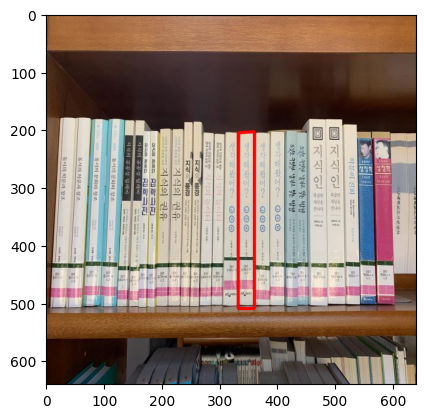

In [5]:
MIN_MATCH_COUNT = 10

# for all scene, compute its local features and descriptions
# then for each model, compute matches
for scene in imgs_scene:
  img_scene = cv2.imread(scene, cv2.IMREAD_COLOR_RGB)

  kp_scene = sift.detect(img_scene)
  kp_scene, des_scene = sift.compute(img_scene, kp_scene)

  for model in imgs_model:

    kp_model = models_dict[model]['keypoints']
    des_model = models_dict[model]['descriptions']

    matches = flann.knnMatch(des_model, des_scene, k=2)

    good = [m for m, n in matches if m.distance < 0.7 * n.distance]


    if len(good) > MIN_MATCH_COUNT:
      src_pts = np.float32([kp_model[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
      dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

      M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

      matches_mask = mask.ravel().tolist()

      h, w = img_model.shape[:2]
      pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

      dst = cv2.perspectiveTransform(pts, M)

      img_train_p = cv2.polylines(img_scene, [np.int32(dst)], True, 255, 3, cv2.LINE_AA)

      print(f"Scene: {scene}, Model: {model}\n\t - {len(good)}/{MIN_MATCH_COUNT}")
      plt.imshow(img_train_p)
      plt.show()

    else:
      print(f"Scene: {scene}, Model: {model}\n\tNot enough matches are found - {len(good)}/{MIN_MATCH_COUNT}")
      matches_mask = None



# Single instance detection

158


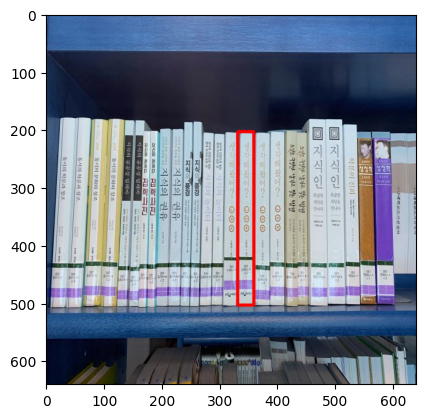

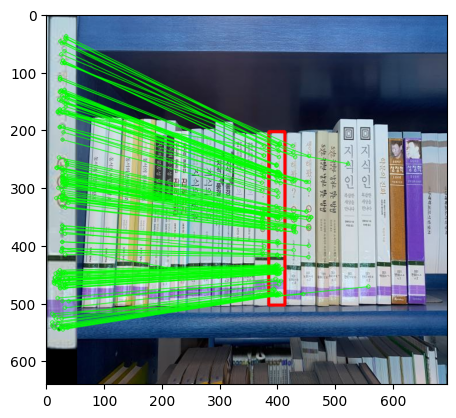

In [12]:
show = True

img_scene = cv2.imread('./dataset/scenes/scene_10.jpg')
img_model = cv2.imread('./dataset/models/model_19.png')

if show and False:
  plt.imshow(img_scene)
  plt.show()
  plt.imshow(img_model)
  plt.show()

sift = cv2.SIFT_create(sigma=0.5)

kp_model = sift.detect(img_model)
kp_scene = sift.detect(img_scene)

if show and False:

  print(len(kp_model))
  img_visualization = cv2.drawKeypoints(img_model, kp_model, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
  plt.imshow(img_visualization)
  plt.show()

  img = cv2.drawKeypoints(img_scene, kp_scene, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
  plt.imshow(img)
  plt.show()

kp_model, des_model = sift.compute(img_model, kp_model)
kp_scene, des_scene = sift.compute(img_scene, kp_scene)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(des_model, des_scene, k=2)

good = [m for m, n in matches if m.distance < 0.8 * n.distance]
# good = [m for m, n in matches]

if show and True:
  print(len(good))

# Checking if enough matches are found
MIN_MATCH_COUNT = 10

if len(good) > MIN_MATCH_COUNT:
    # Building the correspondence arrays of good matches
    src_pts = np.float32([kp_model[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    # Using RANSAC to estimate a robust homography.
    # It returns the homography M and a mask for the discarded points.
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # Mask of discarded point used in visualization
    matches_mask = mask.ravel().tolist()

    # Corners of the model image
    h, w = img_model.shape[:2]
    pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

    # Projecting the corners into the scene image
    dst = cv2.perspectiveTransform(pts, M)

    # Drawing the bounding box
    img_scene = cv2.polylines(img_scene,[np.int32(dst)], True, 255, 3, cv2.LINE_AA)

else:
    print(f"Not enough matches are found - {len(good)}/{MIN_MATCH_COUNT}")
    matches_mask = None


if show and True:
  plt.imshow(img_scene, cmap="gray", vmin=0, vmax=255)
  plt.show()

if show and True:
  # Drawing the matches
  draw_params = dict(
      matchColor=(0, 255, 0),    # draw matches in green color
      singlePointColor=None,     # do not draw keypoints, only matching lines
      # matchesMask=matches_mask,  # draw inliers only
      flags=2
  )
  img3 = cv2.drawMatches(img_model, kp_model, img_scene, kp_scene, good, None, **draw_params)
  plt.imshow(img3, cmap="gray", vmin=0, vmax=0)
  plt.show()

# Old and wrong iterative solution

126


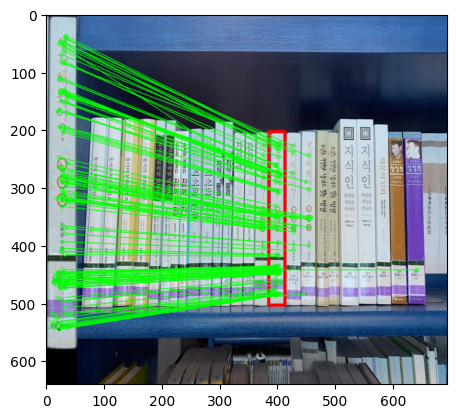

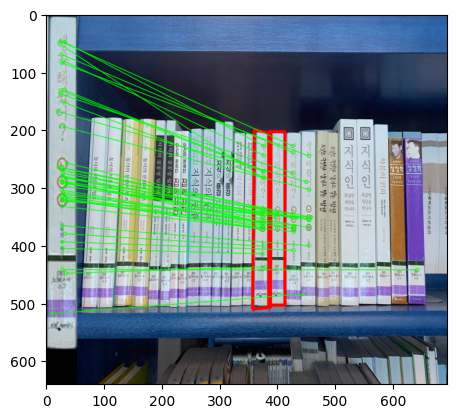

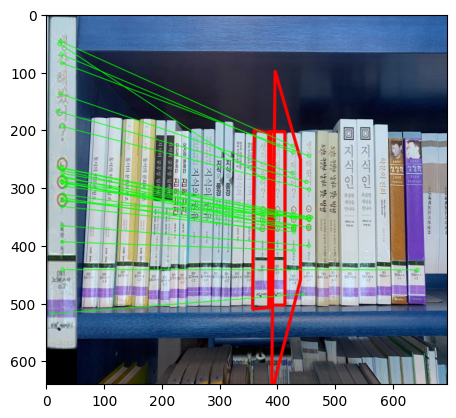

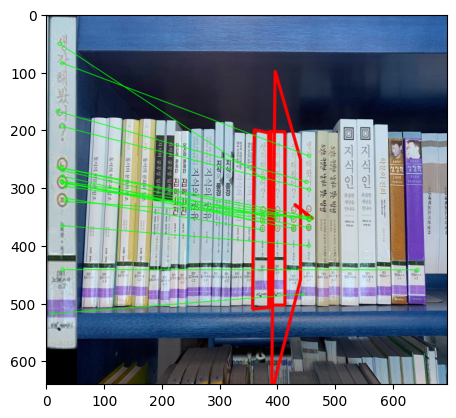

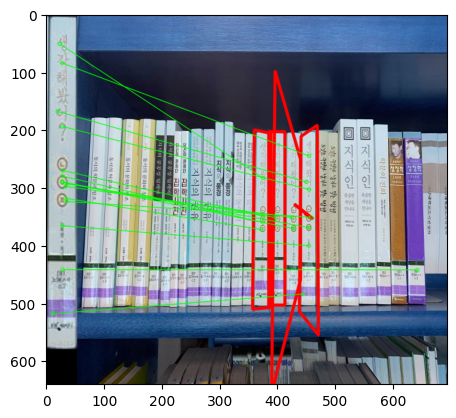

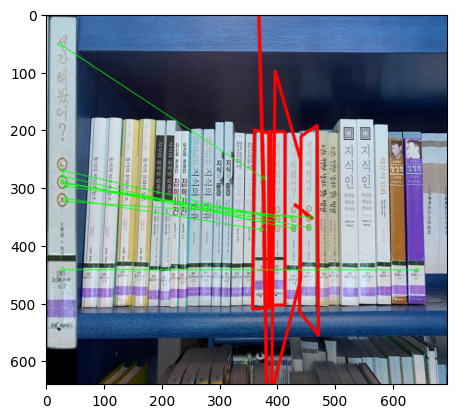

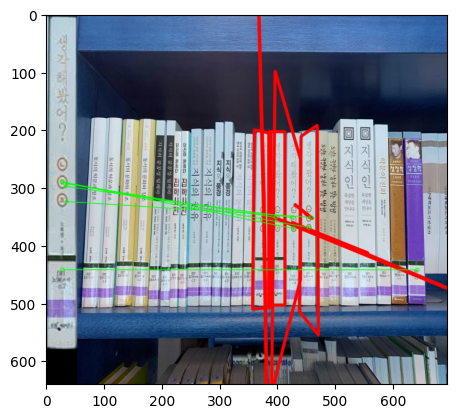

Not enough matches are found - 2/3


In [13]:
show = True

img_scene = cv2.imread('./dataset/scenes/scene_10.jpg')
img_model = cv2.imread('./dataset/models/model_19.png')

if show and False:
  plt.imshow(img_scene)
  plt.show()
  plt.imshow(img_model)
  plt.show()

sift = cv2.SIFT_create(nfeatures=0,                     # default 0
                       nOctaveLayers=3,                 # default 3
                       contrastThreshold=0.04,          # default 0.04
                       edgeThreshold=10,                # default 10
                       sigma=0.5,                      # default 1.6
                       enable_precise_upscale=False     # default False
                       )

kp_model = sift.detect(img_model)
kp_scene = sift.detect(img_scene)

if show and False:

  print(len(kp_model))
  img_visualization = cv2.drawKeypoints(img_model, kp_model, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
  plt.imshow(img_visualization)
  plt.show()

  img = cv2.drawKeypoints(img_scene, kp_scene, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
  plt.imshow(img)
  plt.show()

kp_model, des_model = sift.compute(img_model, kp_model)
kp_scene, des_scene = sift.compute(img_scene, kp_scene)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(des_model, des_scene, k=2)

good = [m for m, n in matches if m.distance < 0.75 * n.distance]

if show and True:
  print(len(good))

# Checking if enough matches are found
MIN_MATCH_COUNT = 3

# Corners of the model image
h, w = img_model.shape[:2]
pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

while len(good) > MIN_MATCH_COUNT:
    # Building the correspondence arrays of good matches
    src_pts = np.float32([kp_model[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    # Using RANSAC to estimate a robust homography.
    # It returns the homography M and a mask for the discarded points.
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    if M is not None:

      # Projecting the corners into the scene image
      dst = cv2.perspectiveTransform(pts, M)

      # Drawing the bounding box
      img_scene = cv2.polylines(img_scene,[np.int32(dst)], True, 255, 3, cv2.LINE_AA)


      if show and False:
        plt.imshow(img_scene, cmap="gray", vmin=0, vmax=255)
        plt.show()

      if show and True:
        # Drawing the matches
        draw_params = dict(
            matchColor=(0, 255, 0),    # draw matches in green color
            singlePointColor=None,     # do not draw keypoints, only matching lines
            # matchesMask=matches_mask,  # draw inliers only
            flags=2
        )
        img3 = cv2.drawMatches(img_model, kp_model, img_scene, kp_scene, good, None, **draw_params)
        plt.imshow(img3, cmap="gray", vmin=0, vmax=0)
        plt.show()

      good = [m for i, m in enumerate(good) if mask[i] == 0]

    else:
        break

else:
    print(f"Not enough matches are found - {len(good)}/{MIN_MATCH_COUNT}")
    matches_mask = None




# Full iterative solution

129


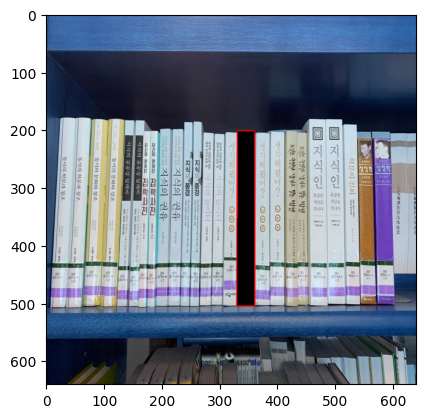

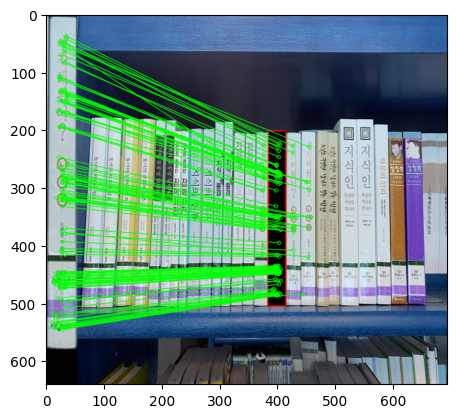

54


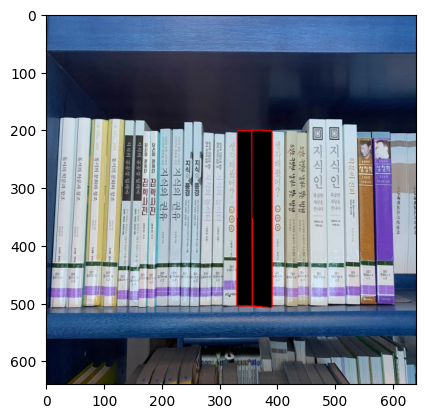

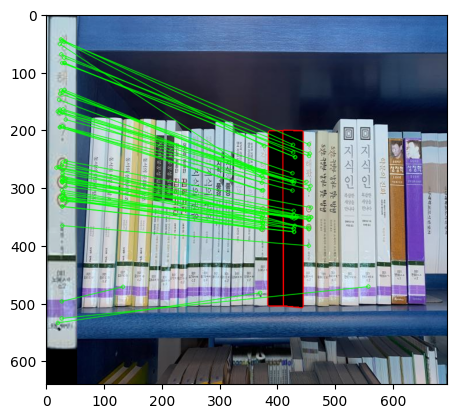

44


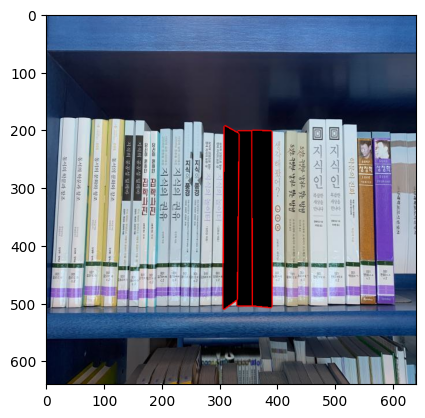

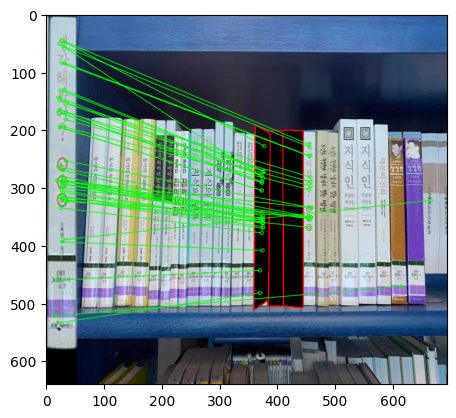

28


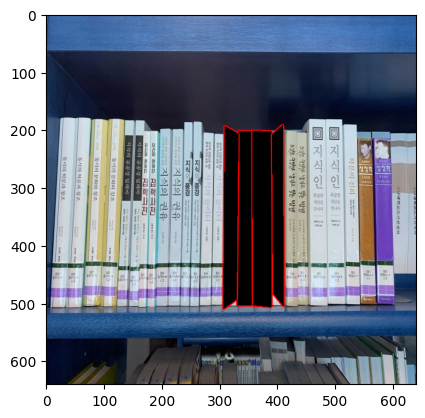

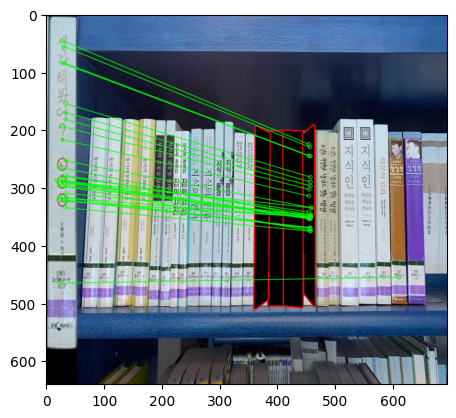

4
Not enough matches are found - 4/10


In [15]:
show = True

img_scene = cv2.imread('./dataset/scenes/scene_10.jpg')
img_model = cv2.imread('./dataset/models/model_19.png')

if show and False:
  plt.imshow(img_scene)
  plt.show()
  plt.imshow(img_model)
  plt.show()

sift = cv2.SIFT_create(sigma=0.5)

while True:

  kp_model = sift.detect(img_model)
  kp_scene = sift.detect(img_scene)

  if show and False:

    print(len(kp_model))
    img_visualization = cv2.drawKeypoints(img_model, kp_model, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.imshow(img_visualization)
    plt.show()

    img = cv2.drawKeypoints(img_scene, kp_scene, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.imshow(img)
    plt.show()

  kp_model, des_model = sift.compute(img_model, kp_model)
  kp_scene, des_scene = sift.compute(img_scene, kp_scene)

  FLANN_INDEX_KDTREE = 1
  index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
  search_params = dict(checks=50)
  flann = cv2.FlannBasedMatcher(index_params, search_params)

  matches = flann.knnMatch(des_model, des_scene, k=2)

  good = [m for m, n in matches if m.distance < 0.75 * n.distance]

  if show and True:
    print(len(good))

  # Checking if enough matches are found
  MIN_MATCH_COUNT = 10

  # Corners of the model image
  h, w = img_model.shape[:2]
  pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

  if len(good) > MIN_MATCH_COUNT:
      # Building the correspondence arrays of good matches
      src_pts = np.float32([kp_model[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
      dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
      # Using RANSAC to estimate a robust homography.
      # It returns the homography M and a mask for the discarded points.
      M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

      # Mask of discarded point used in visualization
      matches_mask = mask.ravel().tolist()

      # Corners of the model image
      h, w = img_model.shape[:2]
      h_t, w_t = img_scene.shape[:2]
      pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

      # Projecting the corners into the scene image
      dst = cv2.perspectiveTransform(pts, M)

      # Drawing the bounding box
      img_scene = cv2.polylines(img_scene,[np.int32(dst)], True, 255, 3, cv2.LINE_AA)

      img_scene = cv2.fillPoly(img_scene, [np.int32(dst)], color=(0,0,0))

      if show and True:
        plt.imshow(img_scene, cmap="gray", vmin=0, vmax=255)
        plt.show()

        # cv2.imwrite('./dataset/scenes/scene_10_2.jpg',img_scene)

      if show and True:
        # Drawing the matches
        draw_params = dict(
            matchColor=(0, 255, 0),    # draw matches in green color
            singlePointColor=None,     # do not draw keypoints, only matching lines
            # matchesMask=matches_mask,  # draw inliers only
            flags=2
        )
        img3 = cv2.drawMatches(img_model, kp_model, img_scene, kp_scene, good, None, **draw_params)
        plt.imshow(img3, cmap="gray", vmin=0, vmax=0)
        plt.show()

  else:
      print(f"Not enough matches are found - {len(good)}/{MIN_MATCH_COUNT}")
      matches_mask = None
      break




# 3. Keypoint clustering solution

108


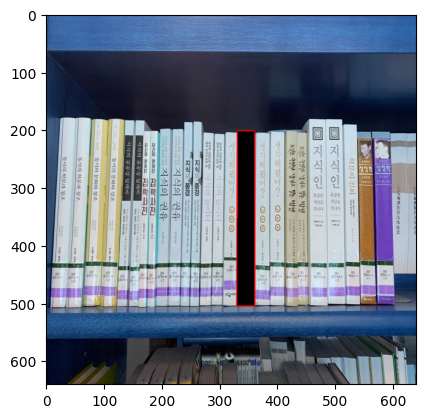

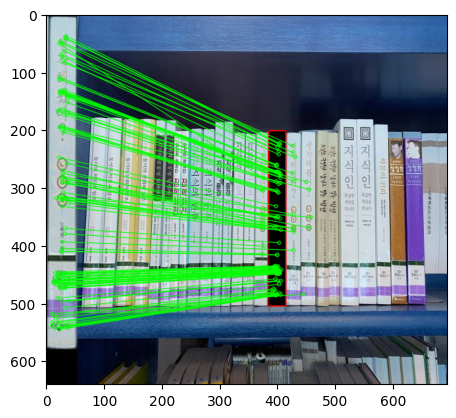

37


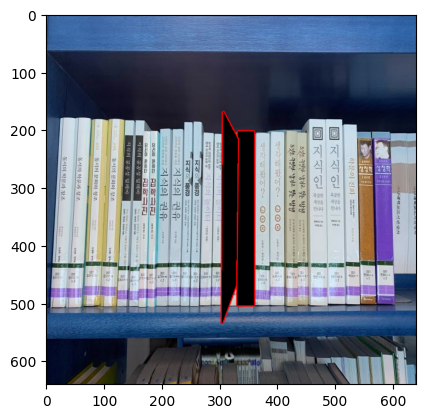

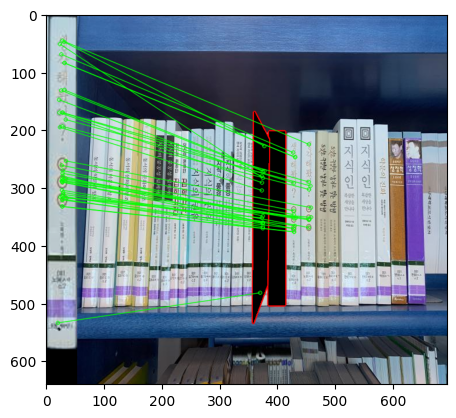

33


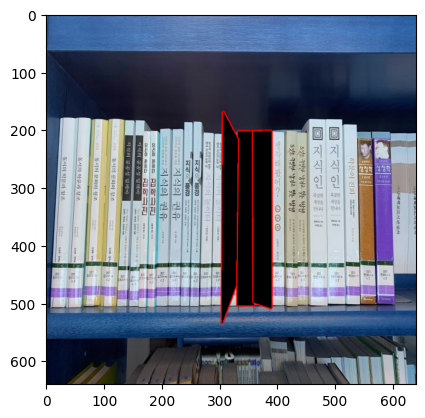

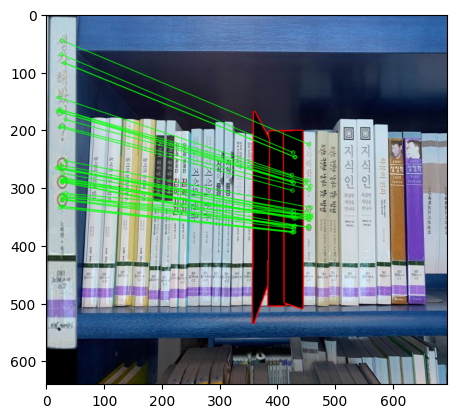

25


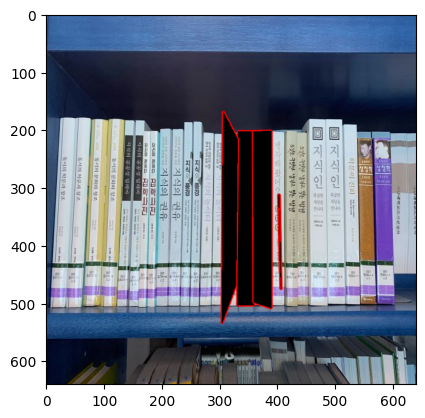

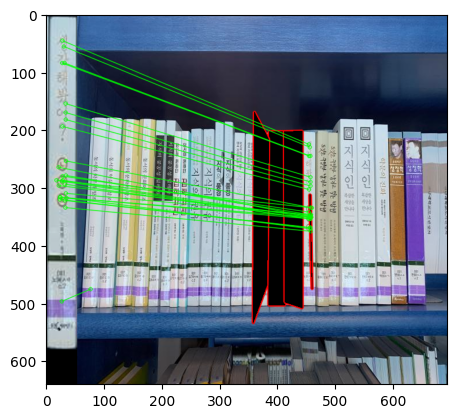

8
Not enough matches are found - 8/10


In [17]:
img_scene = cv2.imread('./dataset/scenes/scene_10.jpg')
img_model = cv2.imread('./dataset/models/model_19.png')

# plt.imshow(img_scene)
# plt.show()
# plt.imshow(img_model)
# plt.show()

sift = cv2.SIFT_create(sigma=0.5)

while True:

  kp_model = sift.detect(img_model)
  kp_scene = sift.detect(img_scene)

  if show and False:

    print(len(kp_model))
    img_visualization = cv2.drawKeypoints(img_model, kp_model, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.imshow(img_visualization)
    plt.show()

    img = cv2.drawKeypoints(img_scene, kp_scene, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.imshow(img)
    plt.show()

  kp_model, des_model = sift.compute(img_model, kp_model)
  kp_scene, des_scene = sift.compute(img_scene, kp_scene)

  FLANN_INDEX_KDTREE = 1
  index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
  search_params = dict(checks=50)
  flann = cv2.FlannBasedMatcher(index_params, search_params)

  matches = flann.knnMatch(des_model, des_scene, k=2)

  good = [m for m, n in matches if m.distance < 0.7 * n.distance]

  if show and True:
    print(len(good))

  # Checking if enough matches are found
  MIN_MATCH_COUNT = 10

  # Corners of the model image
  h, w = img_model.shape[:2]
  pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

  if len(good) > MIN_MATCH_COUNT:
      # Building the correspondence arrays of good matches
      src_pts = np.float32([kp_model[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
      dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
      # Using RANSAC to estimate a robust homography.
      # It returns the homography M and a mask for the discarded points.
      M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

      # Mask of discarded point used in visualization
      matches_mask = mask.ravel().tolist()

      # Corners of the model image
      h, w = img_model.shape[:2]
      h_t, w_t = img_scene.shape[:2]
      pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

      # Projecting the corners into the scene image
      dst = cv2.perspectiveTransform(pts, M)

      # Drawing the bounding box
      img_scene = cv2.polylines(img_scene,[np.int32(dst)], True, 255, 3, cv2.LINE_AA)

      img_scene = cv2.fillPoly(img_scene, [np.int32(dst)], color=(0,0,0))

      if show and True:
        plt.imshow(img_scene, cmap="gray", vmin=0, vmax=255)
        plt.show()

        # cv2.imwrite('./dataset/scenes/scene_10_2.jpg',img_scene)

      if show and True:
        # Drawing the matches
        draw_params = dict(
            matchColor=(0, 255, 0),    # draw matches in green color
            singlePointColor=None,     # do not draw keypoints, only matching lines
            # matchesMask=matches_mask,  # draw inliers only
            flags=2
        )
        img3 = cv2.drawMatches(img_model, kp_model, img_scene, kp_scene, good, None, **draw_params)
        plt.imshow(img3, cmap="gray", vmin=0, vmax=0)
        plt.show()

  else:
      print(f"Not enough matches are found - {len(good)}/{MIN_MATCH_COUNT}")
      matches_mask = None
      break


